# Calculate Coefficient of Variation of yearly precipitation, precipitation in vegetation period and Npp

This script takes in the defined yearly files (currently 2002-2018) and calculates the inter-annual coefficient of variation (standard deviation * 100 / mean) for the yearly precipitation, precipitation in the vegetation period and for Npp. It outputs a raster with 3 bands, one for each CV. A table with all CVs and appends the CVs to each of the yearly data files. 

In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import rioxarray as rxr
import xarray as xr
import rasterio
from rasterio.transform import rowcol

In [4]:
# ---------- Setup ----------

# Define years and variables to calculate CV for
years = list(range(2002, 2019))  # 2002-2018 inclusive
variables = ["pr_sum", "veg_pr_sum", "Npp"]

# Paths to input and output files
tif_paths = {y: f"/Users/Wanja/Documents/non-equilibrium_data/rasters_wgs84_new/stack_wgs84_{y}.tif" for y in years}
parquet_paths = {y: f"/Users/Wanja/Documents/non-equilibrium_data/tables_wgs84_new/table_wgs84_{y}.parquet" for y in years}
output_path = "/Users/Wanja/Documents/non-equilibrium_data/cv_new/"

## Rasters

In [5]:
# ---------- Step 1: find band indices by name (and verify consistency across years) ----------
year_band_maps = {}

for y in years:
    with rasterio.open(tif_paths[y]) as src:
        descriptions = src.descriptions
        name_to_band = {name: i + 1 for i, name in enumerate(descriptions) if name in variables}
        if len(name_to_band) != 3:
            missing = set(variables) - set(name_to_band)
            raise ValueError(f"Year {y}: missing bands for {missing} — check descriptions: {descriptions}")
        year_band_maps[y] = name_to_band

# Confirm the mapping is identical across all years (band position could shift between files)
first_map = year_band_maps[years[0]]
inconsistent_years = [y for y, m in year_band_maps.items() if m != first_map]
if inconsistent_years:
    print(f"WARNING: band order differs in years {inconsistent_years} — using per-year mapping to compensate")
else:
    print(f"Band mapping consistent across all years: {first_map}")

Band mapping consistent across all years: {'pr_sum': 7, 'veg_pr_sum': 14, 'Npp': 17}


In [6]:
# ---------- Step 2: load each year, keeping only the 3 target bands, correctly labeled ----------
das = []
for y in years:
    band_indices = [year_band_maps[y][v] for v in variables]  # order matches `variables`, per-year safe
    da = rxr.open_rasterio(tif_paths[y], masked=True)          # dims: band(1..N), y, x
    da = da.sel(band=band_indices)                              # keep only our 3 bands
    da = da.assign_coords(band=variables)                       # relabel to 'pr_sum','veg_pr_sum','Npp'
    das.append(da)

stack = xr.concat(das, dim=pd.Index(years, name="year"))  # dims: year, band, y, x

In [7]:
# ---------- Step 3: compute CV per pixel, per variable, across years ----------
mean = stack.mean(dim="year", skipna=True)
# Raster: force ddof=1 to match pandas' default
std = stack.std(dim="year", skipna=True, ddof=1)
cv = (std * 100 / mean).where(mean != 0)  # avoid div-by-zero; NaN where mean is exactly 0

crs = stack.rio.crs
cv.rio.write_crs(crs, inplace=True)

/opt/homebrew/Caskroom/miniforge/base/envs/env_non-equilibrium/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


<xarray.DataArray (band: 3, y: 4004, x: 8008)> Size: 385MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(3, 4004, 8008), dtype=float32)
Coordinates:
  * band         (band) <U10 120B 'pr_sum' 'veg_pr_sum' 'Npp'
  * y            (y) float64 32kB 89.98 89.93 89.89 ... -89.89 -89.93 -89.98
  * x            (x) float64 64kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('tmmn_mean', 'tmmx_mean', 'tmmn_min', 'tmmn_max', 'tmmx_...

In [8]:
# ---------- Step 4: save one CV raster with 3 bands + combined plot ----------
cv.attrs.pop("long_name", None)
output_file = output_path + "cv.tif"
cv.rio.to_raster(output_file)

# Explicitly set band descriptions so band names are preserved in the file
with rasterio.open(output_file, "r+") as dst:
    for i, v in enumerate(variables, start=1):  # rasterio bands are 1-indexed
        dst.set_band_description(i, v)

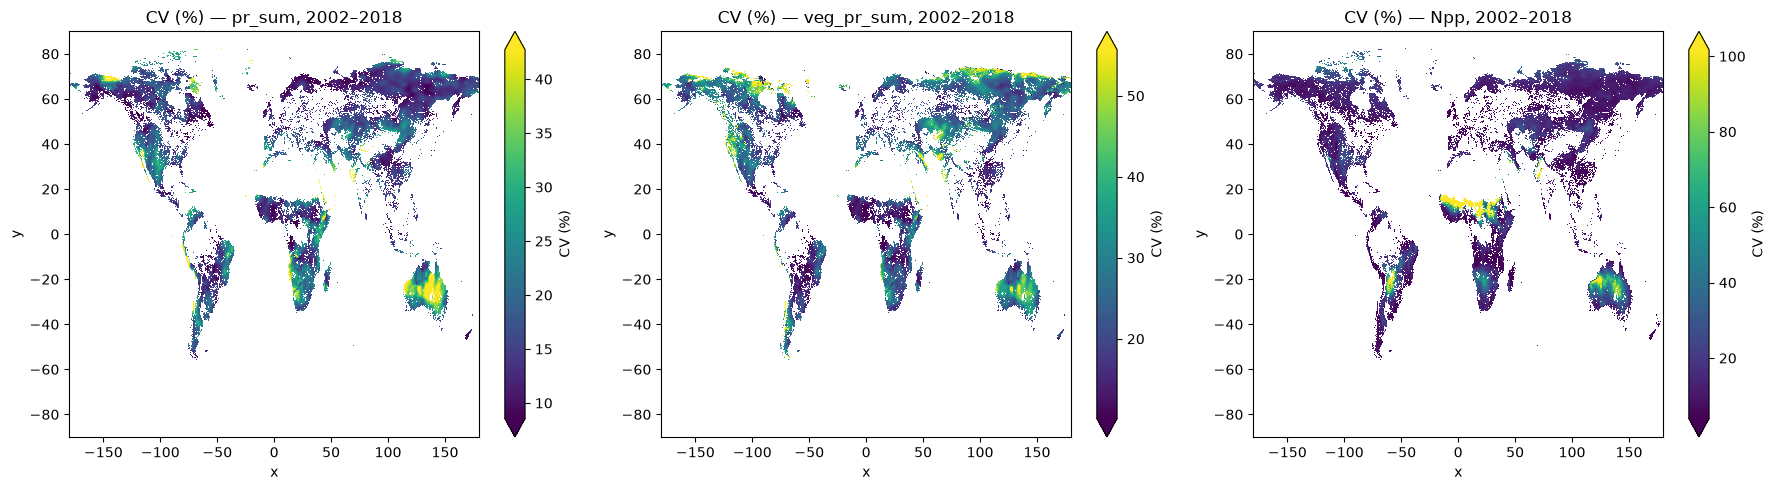

In [9]:
# ---------- Step 5: save combined plot ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, v in zip(axes, variables):
    cv_v = cv.sel(band=v)
    cv_v.plot(ax=ax, cmap="viridis", robust=True, cbar_kwargs={"label": "CV (%)"})
    ax.set_title(f"CV (%) — {v}, 2002–2018")
plt.tight_layout()
plt.savefig(output_path + "cv_raster_maps.png", dpi=200, bbox_inches="tight")
plt.show()

## Tables

In [10]:
# ---------- Concatenate all yearly tables ----------

# round coordinates to avoid floating point issues when grouping (just to be safe, they already contain 6 decimal places)
COORD_DECIMALS = 6

dfs = []
for y, p in parquet_paths.items():
    d = pd.read_parquet(p, columns=["longitude", "latitude"] + variables)
    d["lon_r"] = d["longitude"].round(COORD_DECIMALS)
    d["lat_r"] = d["latitude"].round(COORD_DECIMALS)
    d["year"] = y
    dfs.append(d)

long_df = pd.concat(dfs, ignore_index=True)

# sanity check: every pixel should have all 17 years
counts = long_df.groupby(["lon_r", "lat_r"])["year"].nunique()
n_incomplete = (counts != len(years)).sum()
print(f"{n_incomplete} pixels missing at least one year (out of {len(counts)})")

# Check for duplicate (lon, lat, year) combinations
dupes = long_df.duplicated(subset=["lon_r", "lat_r", "year"]).sum()
print(f"{dupes} duplicate lon/lat/year rows")

# Check total row count makes sense: unique_pixels * 17 years
n_pixels = long_df.groupby(["lon_r", "lat_r"]).ngroups
print(f"{n_pixels} unique pixels, expected total rows: {n_pixels * len(years)}, actual: {len(long_df)}")

0 pixels missing at least one year (out of 4218230)
0 duplicate lon/lat/year rows
4218230 unique pixels, expected total rows: 71709910, actual: 71709910


In [11]:
# ---------- Compute CV per variable ----------
stats = long_df.groupby(["lon_r", "lat_r"])[variables].agg(["mean", "std"])
stats.columns = ["_".join(c) for c in stats.columns]

for v in variables:
    stats[f"{v}_cv"] = np.where(
        stats[f"{v}_mean"] == 0, np.nan,
        stats[f"{v}_std"] * 100 / stats[f"{v}_mean"]
    )

stats = stats.reset_index().rename(columns={"lon_r": "longitude", "lat_r": "latitude"})
cv_cols = [f"{v}_cv" for v in variables]

In [12]:
# ---------- Summary table with all CVs ----------
summary_gdf = gpd.GeoDataFrame(
    stats,
    geometry=[Point(xy) for xy in zip(stats["longitude"], stats["latitude"])],
    crs="EPSG:4326"
)
summary_gdf.to_parquet(output_path + "cv.parquet")

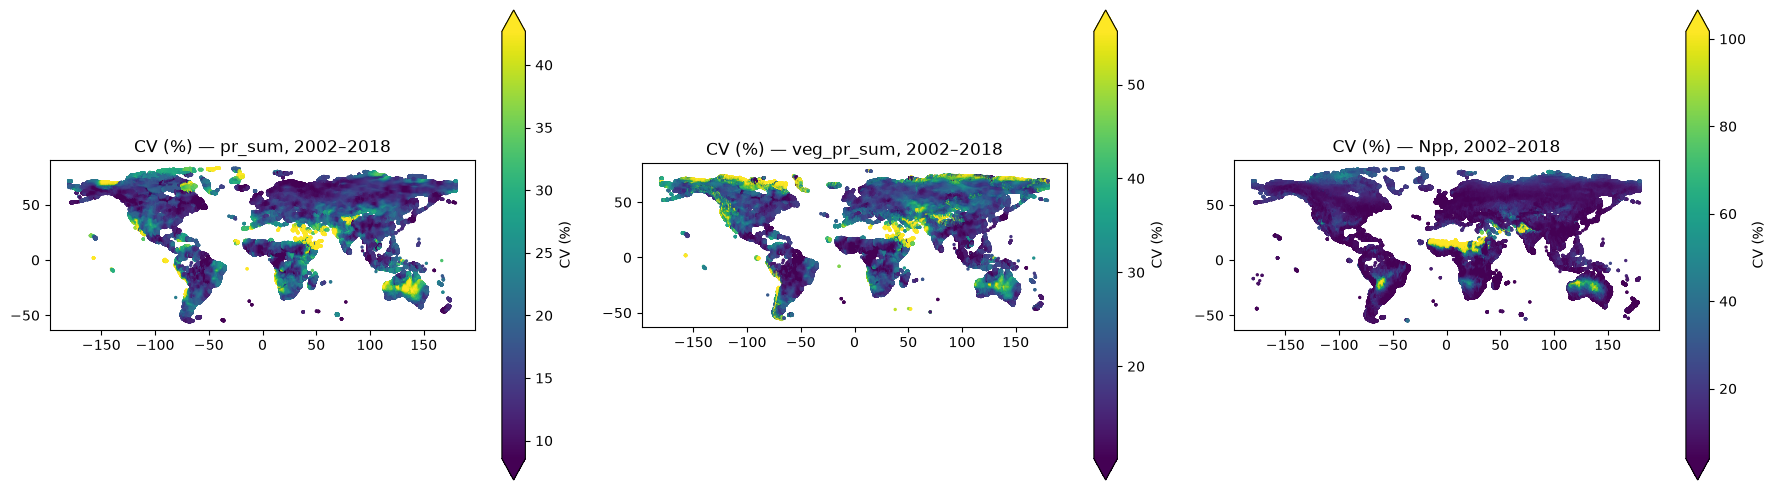

In [13]:
# ---------- Maps ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, v in zip(axes, variables):
    col = f"{v}_cv"
    
    # Robust color limits, ignoring extreme outliers
    vmin, vmax = np.nanpercentile(summary_gdf[col], [2, 98])
    
    summary_gdf.plot(
        column=col, cmap="viridis", legend=True, ax=ax, markersize=2,
        vmin=vmin, vmax=vmax,
        legend_kwds={"label": "CV (%)", "extend": "both"}
    )
    ax.set_title(f"CV (%) — {v}, 2002–2018")
plt.tight_layout()
plt.savefig(output_path + "cv_table_maps.png", dpi=200, bbox_inches="tight")
plt.show()

In [14]:
# ---------- Add cv columns back into each yearly parquet ----------
for y, p in parquet_paths.items():
    d = pd.read_parquet(p)
    d["lon_r"] = d["longitude"].round(COORD_DECIMALS)
    d["lat_r"] = d["latitude"].round(COORD_DECIMALS)
    d = d.merge(
        stats[["longitude", "latitude"] + cv_cols].rename(
            columns={"longitude": "lon_r", "latitude": "lat_r"}
        ),
        on=["lon_r", "lat_r"], how="left"
    )
    d = d.drop(columns=["lon_r", "lat_r"])
    d.to_parquet(output_path + f"table_wgs84_{y}_with_cv.parquet")

## Checks - all good!

### Check raster

In [15]:
with rasterio.open(output_path + "cv.tif") as src:
    print(src.count)         # should be 3
    print(src.descriptions)  # should show ('pr_sum', 'veg_pr_sum', 'Npp')

3
('pr_sum', 'veg_pr_sum', 'Npp')


### Check if raster and table match
Yes they do.

In [16]:
# Take a few sample points from the table
sample = summary_gdf.sample(10, random_state=2)

with rasterio.open(output_path + "cv.tif") as src:
    transform = src.transform
    arr = src.read(1)
    for _, row in sample.iterrows():
        r, c = rowcol(transform, row["longitude"], row["latitude"])
        raster_val = arr[r, c]
        table_val = row["pr_sum_cv"]
        print(f"lon={row['longitude']:.6f}, lat={row['latitude']:.6f} | "
              f"table CV={table_val:.3f} | raster CV={raster_val:.3f} | "
              f"diff={(table_val - raster_val):.3f}")

lon=-0.202298, lat=13.104396 | table CV=10.649 | raster CV=10.649 | diff=-0.000
lon=-69.747752, lat=7.619880 | table CV=19.022 | raster CV=19.022 | diff=-0.000
lon=79.907592, lat=67.814685 | table CV=11.036 | raster CV=11.036 | diff=0.000
lon=-121.176324, lat=67.455045 | table CV=16.328 | raster CV=16.328 | diff=0.000
lon=-98.024476, lat=25.691808 | table CV=17.853 | raster CV=17.853 | diff=0.000
lon=35.087413, lat=37.964535 | table CV=16.842 | raster CV=16.842 | diff=0.000
lon=68.174326, lat=42.684815 | table CV=17.985 | raster CV=17.985 | diff=0.000
lon=-0.921578, lat=49.473027 | table CV=11.580 | raster CV=11.580 | diff=0.000
lon=-73.838661, lat=-12.430070 | table CV=24.327 | raster CV=24.327 | diff=0.000
lon=27.400100, lat=-10.541958 | table CV=11.560 | raster CV=11.560 | diff=0.000


/var/folders/v8/1_2rlmrd0wl5w5t5n60h8s440000gn/T/ipykernel_36165/839610251.py:6: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(1)


### Check missing values

These are the missing values for the mean, std and cv:

In [17]:
print(summary_gdf.isna().sum())
summary_gdf.head(10)

longitude               0
latitude                0
pr_sum_mean          5175
pr_sum_std           5175
veg_pr_sum_mean    240469
veg_pr_sum_std     281442
Npp_mean                0
Npp_std                 0
pr_sum_cv            5207
veg_pr_sum_cv      281474
Npp_cv               5739
geometry                0
dtype: int64


,longitude,latitude,pr_sum_mean,pr_sum_std,veg_pr_sum_mean,veg_pr_sum_std,Npp_mean,Npp_std,pr_sum_cv,veg_pr_sum_cv,Npp_cv,geometry
0,-179.977522,65.656843,521.657654,99.407524,127.323380,45.762890,1669.696533,266.736450,19.056084,35.942253,15.975145,POINT (-179.97752 65.65684)
1,-179.977522,65.701798,521.250610,99.533180,133.973724,44.443874,1692.086426,270.561615,19.095074,33.173573,15.989822,POINT (-179.97752 65.7018)
2,-179.977522,65.791708,520.744202,99.678268,136.008987,48.891315,1740.287231,284.191986,19.141504,35.947121,16.330177,POINT (-179.97752 65.79171)
3,-179.977522,66.331169,517.834778,102.001877,110.250595,47.543285,819.857910,147.639252,19.697765,43.122929,18.007906,POINT (-179.97752 66.33117)
4,-179.977522,66.376124,520.551453,102.784508,106.219727,47.060814,768.429199,143.876862,19.745312,44.305157,18.723503,POINT (-179.97752 66.37612)
5,-179.977522,66.421079,520.915466,102.874489,104.632965,44.272808,530.583496,99.311630,19.748789,42.312485,18.717438,POINT (-179.97752 66.42108)
6,-179.977522,66.510989,525.939331,103.360504,90.991585,40.288883,604.548340,127.002831,19.652554,44.277596,21.007887,POINT (-179.97752 66.51099)
7,-179.977522,66.555944,527.357300,103.220413,82.345711,36.471653,732.283691,161.119415,19.573145,44.290897,22.002321,POINT (-179.97752 66.55594)
8,-179.977522,66.600899,526.854675,102.730850,77.880180,33.879326,699.032288,152.252014,19.498898,43.501858,21.780397,POINT (-179.97752 66.6009)
9,-179.977522,66.645854,522.964722,101.608040,75.842361,35.600216,651.200684,148.441620,19.429234,46.939751,22.795065,POINT (-179.97752 66.64585)


Since the std needs at least 2 years with valid numbers (not nan) to be estimated, it has more missing values. This is the amount of pixels that have only 1, 2 etc. years of data:

In [18]:
# Using your long_df (long format, one row per pixel-year)
valid_counts = (
    long_df.dropna(subset=["veg_pr_sum"])
    .groupby(["lon_r", "lat_r"])
    .size()
)

print(valid_counts.value_counts().sort_index())

1       40973
2       27159
3       17419
4       16645
5       14816
6       12598
7       12976
8       15367
9       17885
10      17423
11      20683
12      20475
13      21542
14      27891
15      36218
16      62084
17    3595607
Name: count, dtype: int64


Hence, the standard deviation has 40973 more missing values than the mean:

In [19]:
240469 + 40973 == 281442

True

So, we have 3 sources of missing values:
- the mean is 0, so we cannot calculate the cv bc it would divide by 0
- the mean is nan
- the std is nan

This gives us the following expected number of missing values, which is the same as the actual number of missing values:

In [20]:
for v in variables:
    expected_nan_pixels = (
        (summary_gdf[f"{v}_mean"] == 0) |
        (summary_gdf[f"{v}_mean"].isna()) |
        (summary_gdf[f"{v}_std"].isna())
    ).sum()
    actual_nan_pixels = summary_gdf[f"{v}_cv"].isna().sum()
    print(f"{v}: expected NaN (mean==0) = {expected_nan_pixels}, actual NaN in cv = {actual_nan_pixels}")

pr_sum: expected NaN (mean==0) = 5207, actual NaN in cv = 5207
veg_pr_sum: expected NaN (mean==0) = 281474, actual NaN in cv = 281474
Npp: expected NaN (mean==0) = 5739, actual NaN in cv = 5739


This is the same for the individual files, so the merge was correct, too:

In [21]:
cv_cols = [f"{v}_cv" for v in variables]  # ['pr_sum_cv', 'veg_pr_sum_cv', 'Npp_cv']

for y in years:
    d = pd.read_parquet(output_path + f"table_wgs84_{y}_with_cv.parquet")
    n_total = len(d)
    print(f"--- Year {y} (n={n_total}) ---")
    for col in cv_cols:
        n_nan = d[col].isna().sum()
        pct = 100 * n_nan / n_total
        print(f"  {col}: {n_nan} NaN ({pct:.3f}%)")

--- Year 2002 (n=4218230) ---
  pr_sum_cv: 5207 NaN (0.123%)
  veg_pr_sum_cv: 281474 NaN (6.673%)
  Npp_cv: 5739 NaN (0.136%)
--- Year 2003 (n=4218230) ---
  pr_sum_cv: 5207 NaN (0.123%)
  veg_pr_sum_cv: 281474 NaN (6.673%)
  Npp_cv: 5739 NaN (0.136%)
--- Year 2004 (n=4218230) ---
  pr_sum_cv: 5207 NaN (0.123%)
  veg_pr_sum_cv: 281474 NaN (6.673%)
  Npp_cv: 5739 NaN (0.136%)
--- Year 2005 (n=4218230) ---
  pr_sum_cv: 5207 NaN (0.123%)
  veg_pr_sum_cv: 281474 NaN (6.673%)
  Npp_cv: 5739 NaN (0.136%)
--- Year 2006 (n=4218230) ---
  pr_sum_cv: 5207 NaN (0.123%)
  veg_pr_sum_cv: 281474 NaN (6.673%)
  Npp_cv: 5739 NaN (0.136%)
--- Year 2007 (n=4218230) ---
  pr_sum_cv: 5207 NaN (0.123%)
  veg_pr_sum_cv: 281474 NaN (6.673%)
  Npp_cv: 5739 NaN (0.136%)
--- Year 2008 (n=4218230) ---
  pr_sum_cv: 5207 NaN (0.123%)
  veg_pr_sum_cv: 281474 NaN (6.673%)
  Npp_cv: 5739 NaN (0.136%)
--- Year 2009 (n=4218230) ---
  pr_sum_cv: 5207 NaN (0.123%)
  veg_pr_sum_cv: 281474 NaN (6.673%)
  Npp_cv: 5739 NaN (

### Check columns

Looks good, except geometry column.

In [22]:
pd.set_option("display.max_columns", None)  # show all columns, don't truncate
df = pd.read_parquet(output_path + "table_wgs84_2002_with_cv.parquet")  # or whichever year
print(df.head())

   tmmn_mean  tmmx_mean   tmmn_min  tmmn_max   tmmx_min  tmmx_max     pr_sum  \
0 -21.713673 -16.394840 -41.490128 -1.909845 -35.943695  2.363811  93.000000   
1 -21.698551 -16.381865 -41.464275 -1.909932 -35.920094  2.360824  92.973320   
2 -21.678333 -16.364655 -41.429546 -1.910021 -35.888828  2.356767  92.928581   
3 -21.657988 -16.347395 -41.393475 -1.910310 -35.857037  2.352308  92.887970   
4 -21.639671 -16.331858 -41.361004 -1.910570 -35.828419  2.348294  92.851418   

   veg_tmmn_mean  veg_tmmx_mean  veg_tmmn_min  veg_tmmn_max  veg_tmmx_min  \
0            NaN            NaN           NaN           NaN           NaN   
1            NaN            NaN           NaN           NaN           NaN   
2            NaN            NaN           NaN           NaN           NaN   
3            NaN            NaN           NaN           NaN           NaN   
4            NaN            NaN           NaN           NaN           NaN   

   veg_tmmx_max  veg_pr_sum  vegetation_length          

In [23]:
# Load the summary stats table (has one row per pixel with the cv columns)
stats_check = gpd.read_parquet(output_path + "cv.parquet")  # or however you saved 'stats'
stats_check.head(10)

,longitude,latitude,pr_sum_mean,pr_sum_std,veg_pr_sum_mean,veg_pr_sum_std,Npp_mean,Npp_std,pr_sum_cv,veg_pr_sum_cv,Npp_cv,geometry
0,-179.977522,65.656843,521.657654,99.407524,127.323380,45.762890,1669.696533,266.736450,19.056084,35.942253,15.975145,POINT (-179.97752 65.65684)
1,-179.977522,65.701798,521.250610,99.533180,133.973724,44.443874,1692.086426,270.561615,19.095074,33.173573,15.989822,POINT (-179.97752 65.7018)
2,-179.977522,65.791708,520.744202,99.678268,136.008987,48.891315,1740.287231,284.191986,19.141504,35.947121,16.330177,POINT (-179.97752 65.79171)
3,-179.977522,66.331169,517.834778,102.001877,110.250595,47.543285,819.857910,147.639252,19.697765,43.122929,18.007906,POINT (-179.97752 66.33117)
4,-179.977522,66.376124,520.551453,102.784508,106.219727,47.060814,768.429199,143.876862,19.745312,44.305157,18.723503,POINT (-179.97752 66.37612)
5,-179.977522,66.421079,520.915466,102.874489,104.632965,44.272808,530.583496,99.311630,19.748789,42.312485,18.717438,POINT (-179.97752 66.42108)
6,-179.977522,66.510989,525.939331,103.360504,90.991585,40.288883,604.548340,127.002831,19.652554,44.277596,21.007887,POINT (-179.97752 66.51099)
7,-179.977522,66.555944,527.357300,103.220413,82.345711,36.471653,732.283691,161.119415,19.573145,44.290897,22.002321,POINT (-179.97752 66.55594)
8,-179.977522,66.600899,526.854675,102.730850,77.880180,33.879326,699.032288,152.252014,19.498898,43.501858,21.780397,POINT (-179.97752 66.6009)
9,-179.977522,66.645854,522.964722,101.608040,75.842361,35.600216,651.200684,148.441620,19.429234,46.939751,22.795065,POINT (-179.97752 66.64585)


### Check row count before and after adding cv 

Is the same.

In [24]:
for y in years:
    d_before = pd.read_parquet(parquet_paths[y])
    d_after = pd.read_parquet(output_path + f"table_wgs84_{y}_with_cv.parquet")
    if len(d_before) != len(d_after):
        print(f"WARNING Year {y}: row count changed! before={len(d_before)}, after={len(d_after)}")

## Questions

- do i first need to normalize precipitation in the vegetation period with the length of the vegetation period??
